In [1]:
import glob
import json
import random
from copy import deepcopy as dc
from os.path import join as opj

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from scipy.stats import spearmanr

from cloth_fmri.config.config import CONFIG
from cloth_fmri.utils.stats import (
    bootstrap_ci,
    bootstrap_cor,
    calc_p,
)
from cloth_fmri.utils.plot import plot_scene_bar_with_points, plot_bootstrap_violin
from cloth_fmri.utils.svm import (
    get_cnn_distance,
    get_woven_distance,
    get_videomae_distance,
    get_vivit_distance,
    get_vjepa2_distance
)


random.seed(9)

/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/nilearn/__init__.py:67: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


In [2]:
model_order = ["Woven", "V-JEPA2", "VideoMAE", "ViViT", "CNN"]

model_distance = {
    "Woven": get_woven_distance(verbose=False),
    "V-JEPA2": get_vjepa2_distance(verbose=False),
    "VideoMAE": get_videomae_distance(verbose=False),
    "ViViT": get_vivit_distance(verbose=False),
    "CNN": get_cnn_distance(verbose=False),
}


rois = ["tower", "v1"]

In [3]:
human_acc = {}
best_svm = {}

for roi in rois:
    best_split_half_r_all_subs = -1
    best_split_half_p = None
    best_all_acc_means = None
    best_bootstrap_correlation = None
    best_params = None

    for leave_scene in ["1", "2"]:
        for C in ["0.1", "1.0", "10.0", "100.0"]:
            for smooth in ["0", "1", "2"]:

                input_dir = opj(
                    CONFIG["output_root"],
                    "analysis",
                    "fig3",
                    f"leave-{leave_scene}-run-out",
                    f"C={C}",
                    f"smooth={smooth}",
                    roi,
                )

                files = glob.glob(opj(input_dir, "*.json"), recursive=False)

                if len(files) == 0:
                    continue

                all_data = []

                for f in files:
                    with open(f, "r") as f_obj:
                        data = json.load(f_obj)["tower_acc_all_tmps"]

                    for key_sub in data:
                        for key_scene in data[key_sub]:
                            data[key_sub][key_scene] = np.mean(
                                data[key_sub][key_scene]
                            )

                    scene_order = CONFIG["scenes"]
                    subjects = sorted(data.keys())

                    array_2d = np.array([
                        [data[subj][scene] for scene in scene_order]
                        for subj in subjects
                    ])

                    all_data.append(array_2d)

                all_acc_means = np.mean(np.array(all_data), axis=0)

                split_half_r_all_subs, p, bootstrap_correlations = bootstrap_cor(all_acc_means, seed=99)

                if split_half_r_all_subs > best_split_half_r_all_subs:
                    best_split_half_r_all_subs = split_half_r_all_subs
                    best_split_half_p = p
                    best_bootstrap_correlation = dc(bootstrap_correlations)
                    best_all_acc_means = dc(all_acc_means)
                    best_params = {
                        "leave_scene": leave_scene,
                        "C": C,
                        "smooth": smooth,
                        "input_dir": input_dir,
                    }

    human_acc[roi] = dc(best_all_acc_means)

    best_svm[roi] = {
        "split_half_r": best_split_half_r_all_subs,
        "split_half_p": best_split_half_p,
        "bootstrap_correlation": dc(best_bootstrap_correlation),
        "acc": dc(best_all_acc_means),
        "params": dc(best_params),
    }

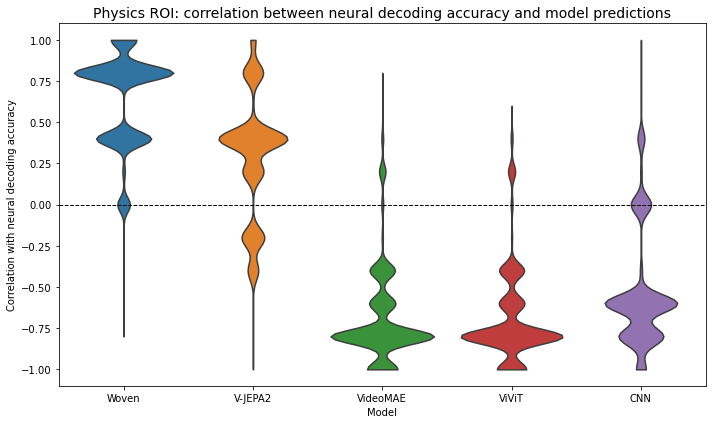

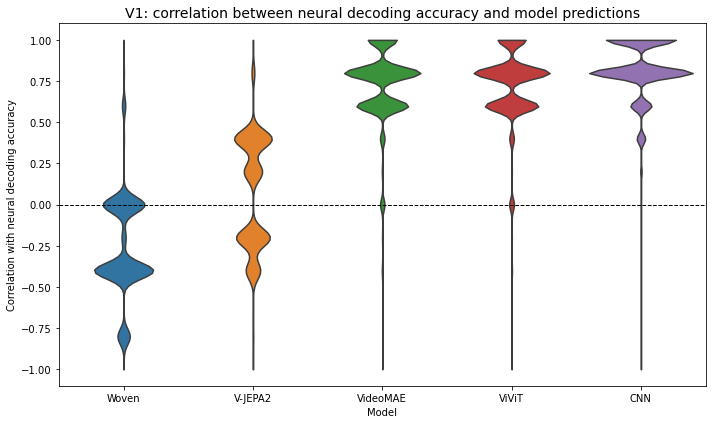

In [4]:
# ----------------------------------------------------
# Compute model mean profiles for all five models
# ----------------------------------------------------
model_order = ["Woven", "V-JEPA2", "VideoMAE", "ViViT", "CNN"]

model_mean = {}

for model_name in model_order:
    model_mean[model_name] = [
        np.mean(model_distance[model_name][scene][:62])
        for scene in CONFIG["scenes"]
    ]


# ----------------------------------------------------
# Bootstrap correlation between neural accuracy and all five models
# ----------------------------------------------------

roi_acc = {
    "Physics ROI": human_acc["tower"],
    "V1": human_acc["v1"],
}

roi_order = ["Physics ROI", "V1"]

model_cor = {}

for roi_name in roi_order:
    acc = roi_acc[roi_name]
    model_cor[roi_name] = {}

    nsub = acc.shape[0]

    for model_name in model_order:
        cur_cor = []

        for curboot in range(10000):
            human_boot_indices = np.random.choice(nsub, nsub, replace=True)
            human_boot = acc[human_boot_indices, :]
            human_boot_acc_across_scenes = np.mean(human_boot, axis=0)

            cur_r, _ = spearmanr(
                model_mean[model_name],
                human_boot_acc_across_scenes,
            )

            cur_cor.append(cur_r)

        model_cor[roi_name][model_name] = dc(cur_cor)


# ----------------------------------------------------
# Plot all five models: one figure per ROI
# ----------------------------------------------------

for roi_name in roi_order:
    plot_rows = []

    for model_name in model_order:
        for r in model_cor[roi_name][model_name]:
            plot_rows.append({
                "Model": model_name,
                "Spearman r": r,
            })

    plot_df = pd.DataFrame(plot_rows)

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.violinplot(
        data=plot_df,
        x="Model",
        y="Spearman r",
        order=model_order,
        ax=ax,
        inner=None,
        cut=0,
    )

    ax.axhline(
        y=0.0,
        color="black",
        linestyle="--",
        linewidth=1,
    )

    ax.set_title(
        f"{roi_name}: correlation between neural decoding accuracy and model predictions",
        fontsize=14,
    )
    ax.set_xlabel("Model")
    ax.set_ylabel("Correlation with neural decoding accuracy")

    plt.tight_layout()
    plt.show()